# 01_preprocessing_check

전처리된 KMP 통신사 이탈 데이터의 기본 구조, 라벨 분포, 전환 구조, 주요 입력 변수 분포를 확인한다.

## 1. 전처리 데이터 기본 구조 및 라벨 확인

이 섹션에서는 전처리된 데이터가 어떤 단위로 구성되어 있는지,
라벨이 어떤 비율로 분포하는지, 통신사 이동 구조가 어떻게 나타나는지를 확인한다.

특히 아래 내용을 중심으로 살펴본다.

- 한 행이 무엇을 의미하는지
- 전체 통신사 변경 여부(`churn_any`) 분포
- 메이저 통신사에서 MVNO로 이동한 경우(`churn_to_mvno`) 분포
- 연도 전환 구간별 표본 수
- 시작 통신사 분포
- 실제 통신사 이동 방향
- 시작 통신사별 이탈 비율

이를 통해 전처리된 CSV가 전체적으로 어떤 구조를 가지는지 먼저 파악한다.

1. 전처리 데이터 기본 구조 확인
데이터 크기(shape): 41,299행 × 16열

컬럼 목록
['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'telco_t0_name', 'telco_t1_name']

상위 5행
       pid  year_t0  year_t1  telco_t0  telco_t1  churn_any  churn_to_mvno  \
0  1000001     2020     2021       2.0       1.0          1              0   
1  1000001     2021     2022       1.0       1.0          0              0   
2  1000001     2022     2023       1.0       1.0          0              0   
3  1000001     2023     2024       1.0       1.0          0              0   
4  1000001     2024     2025       1.0       3.0          1              0   

   a03002_tminus1  a03024_tminus1  a03026_tminus1  c01002_tminus1  \
0             2.0             0.0             0.0             4.0   
1             2.0             1.0             0.0             5.0   
2             3.0

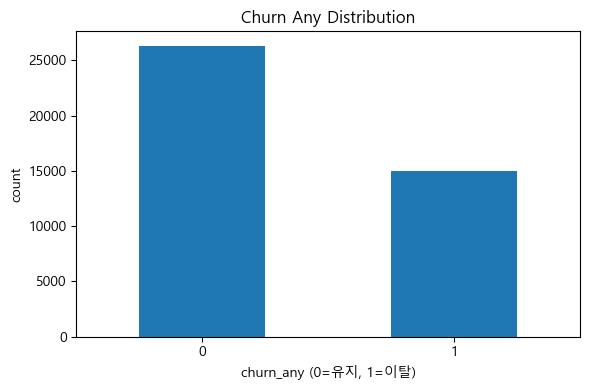


2. churn_any 분포
- 유지(0): 26,317건 (63.72%)
- 이탈(1): 14,982건 (36.28%)

[해석] churn_any
- churn_any는 '통신사가 바뀌었는가?'를 가장 넓게 정의한 라벨이다.
- 0은 통신사를 유지한 경우, 1은 통신사를 변경한 경우다.
- 이 비율을 보면 전체 데이터에서 이탈 사례가 얼마나 있는지 알 수 있다.
- 양성(1) 비율이 너무 작지 않으면, 통신사 변경 여부 예측 문제로 다루기 좋은 구조라고 볼 수 있다.


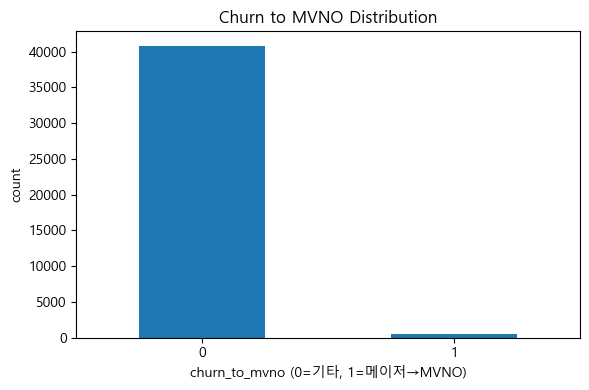


3. churn_to_mvno 분포
- 기타(0): 40,784건 (98.75%)
- 메이저→MVNO(1): 515건 (1.25%)

[해석] churn_to_mvno
- churn_to_mvno는 '메이저 통신사에서 알뜰폰으로 이동했는가?'만 따로 본 라벨이다.
- 전체 이탈보다 훨씬 좁은 개념이라서 양성(1) 비율이 매우 낮은 경우가 많다.
- 이 그래프는 MVNO 이동이 얼마나 희소한 사건인지 보여준다.
- 이후 모델링에서는 Accuracy보다 Recall, Precision, F1, PR-AUC 같은 지표를 함께 보는 것이 중요하다.


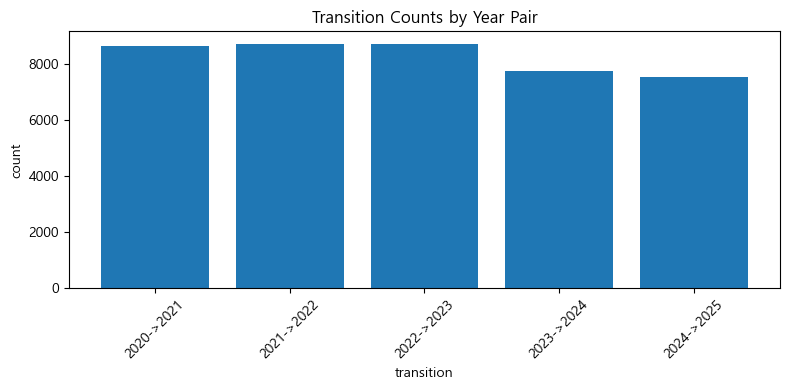


4. 연도 전환 구간별 건수
- 2020->2021: 8,612건
- 2021->2022: 8,708건
- 2022->2023: 8,714건
- 2023->2024: 7,730건
- 2024->2025: 7,535건

[해석] 연도 전환 구간
- 이 그래프는 각 연도 구간(예: 2020->2021, 2021->2022)에 몇 개의 전환 행이 있는지를 보여준다.
- 특정 구간의 건수가 유난히 적다면, 그 시기의 결과는 표본 수가 적어서 해석에 주의가 필요하다.
- 연도별 건수 차이는 패널 유지율, 조사 누락, 유효 통신사 필터링 등의 영향을 받을 수 있다.


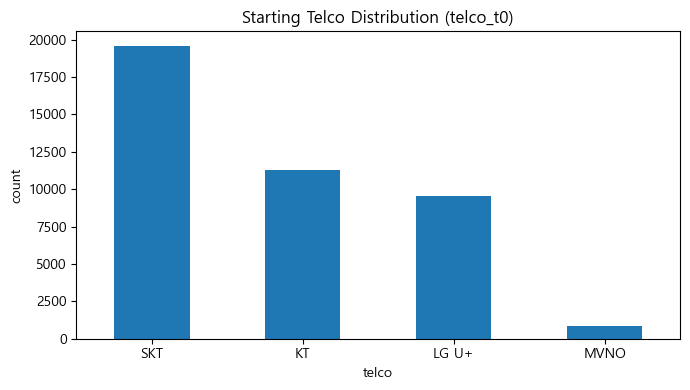


5. 시작 통신사 분포
- SKT: 19,579건 (47.41%)
- KT: 11,295건 (27.35%)
- LG U+: 9,566건 (23.16%)
- MVNO: 859건 (2.08%)

[해석] 시작 통신사 분포
- 이 그래프는 전환이 시작되는 시점(t-1)에 어떤 통신사를 사용 중인 사람이 많은지를 보여준다.
- 전체 데이터 구성에서 어떤 통신사 이용자가 큰 비중을 차지하는지 파악할 수 있다.
- 이후 이동 건수나 이탈률을 해석할 때 기준점 역할을 한다.


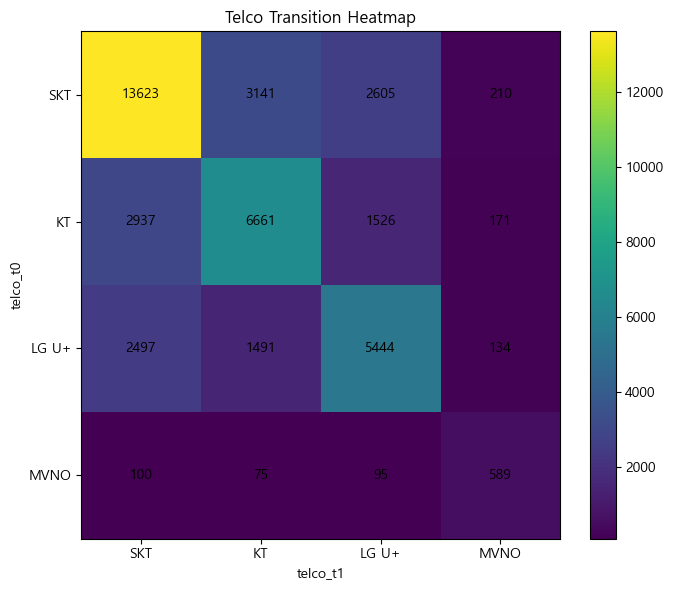


6. 통신사 이동 heatmap
telco_t1_name    SKT    KT  LG U+  MVNO
telco_t0_name                          
SKT            13623  3141   2605   210
KT              2937  6661   1526   171
LG U+           2497  1491   5444   134
MVNO             100    75     95   589

[해석] 통신사 이동 heatmap
- 행(row)은 시작 통신사(t-1), 열(column)은 다음 연도 통신사(t)를 뜻한다.
- 대각선 값이 크면 같은 통신사를 유지한 경우가 많다는 뜻이다.
- 대각선 바깥 값이 크면 실제 통신사 이동이 많이 발생했다는 뜻이다.
- 어떤 통신사에서 어디로 이동이 많이 일어나는지 한눈에 보여주는 핵심 그래프다.


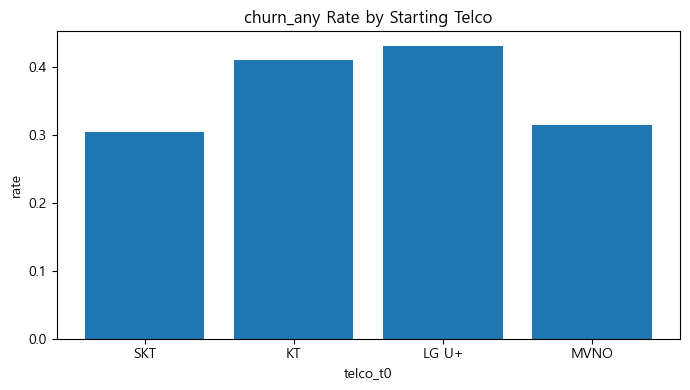


7. 시작 통신사별 churn_any 비율
- SKT: 30.42%
- KT: 41.03%
- LG U+: 43.09%
- MVNO: 31.43%

[해석] 시작 통신사별 이탈률
- 이 그래프는 어느 통신사에서 출발한 이용자가 상대적으로 더 많이 이동하는지를 보여준다.
- 시작 통신사 분포가 절대 규모를 보여줬다면, 이 그래프는 비율 관점 비교다.
- 이동 건수와 이탈률은 다른 의미이므로 둘을 함께 봐야 해석이 정확해진다.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
# ---------------------------------------
# 0. 데이터 불러오기
# ---------------------------------------
# notebooks 폴더 기준 한 단계 위의 data/processed 폴더에서 CSV를 읽음
df = pd.read_csv("../data/processed/train_df_2020_2025.csv", encoding="utf-8-sig")

# 통신사 코드 -> 이름 매핑
# 그래프를 숫자 대신 이름으로 보여주기 위해 사용
telco_map = {
    1.0: "SKT",
    2.0: "KT",
    3.0: "LG U+",
    4.0: "MVNO"
}

df["telco_t0_name"] = df["telco_t0"].map(telco_map)
df["telco_t1_name"] = df["telco_t1"].map(telco_map)

# ---------------------------------------
# 1. 기본 구조 확인
# ---------------------------------------
print("=" * 70)
print("1. 전처리 데이터 기본 구조 확인")
print("=" * 70)
print(f"데이터 크기(shape): {df.shape[0]:,}행 × {df.shape[1]:,}열")

print("\n컬럼 목록")
print(df.columns.tolist())

print("\n상위 5행")
print(df.head())

print("\n[해석] 기본 구조")
print("- 이 데이터는 '한 사람의 한 번의 연도 전환(t-1 -> t)'을 1행으로 표현한 패널 데이터다.")
print("- 같은 pid가 여러 행에 등장할 수 있으며, 이는 같은 사람이 여러 연도 구간에서 반복 관측되기 때문이다.")
print("- year_t0는 입력 피처가 속한 연도이고, year_t1은 결과가 확인되는 다음 연도다.")
print("- telco_t0는 시작 통신사, telco_t1은 다음 연도 통신사다.")
print("- churn_any와 churn_to_mvno는 예측 대상(label)이다.")
print("- telco_t1은 다음 연도 결과를 담고 있으므로 모델 입력으로 사용하면 안 된다.")

# ---------------------------------------
# 2. churn_any 분포
# ---------------------------------------
counts_any = df["churn_any"].value_counts().sort_index()
ratio_any = df["churn_any"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 4))
counts_any.plot(kind="bar")
plt.title("Churn Any Distribution")
plt.xlabel("churn_any (0=유지, 1=이탈)")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("2. churn_any 분포")
print("=" * 70)
print(f"- 유지(0): {counts_any.get(0, 0):,}건 ({ratio_any.get(0, 0):.2%})")
print(f"- 이탈(1): {counts_any.get(1, 0):,}건 ({ratio_any.get(1, 0):.2%})")

print("\n[해석] churn_any")
print("- churn_any는 '통신사가 바뀌었는가?'를 가장 넓게 정의한 라벨이다.")
print("- 0은 통신사를 유지한 경우, 1은 통신사를 변경한 경우다.")
print("- 이 비율을 보면 전체 데이터에서 이탈 사례가 얼마나 있는지 알 수 있다.")
print("- 양성(1) 비율이 너무 작지 않으면, 통신사 변경 여부 예측 문제로 다루기 좋은 구조라고 볼 수 있다.")

# ---------------------------------------
# 3. churn_to_mvno 분포
# ---------------------------------------
counts_mvno = df["churn_to_mvno"].value_counts().sort_index()
ratio_mvno = df["churn_to_mvno"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 4))
counts_mvno.plot(kind="bar")
plt.title("Churn to MVNO Distribution")
plt.xlabel("churn_to_mvno (0=기타, 1=메이저→MVNO)")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("3. churn_to_mvno 분포")
print("=" * 70)
print(f"- 기타(0): {counts_mvno.get(0, 0):,}건 ({ratio_mvno.get(0, 0):.2%})")
print(f"- 메이저→MVNO(1): {counts_mvno.get(1, 0):,}건 ({ratio_mvno.get(1, 0):.2%})")

print("\n[해석] churn_to_mvno")
print("- churn_to_mvno는 '메이저 통신사에서 알뜰폰으로 이동했는가?'만 따로 본 라벨이다.")
print("- 전체 이탈보다 훨씬 좁은 개념이라서 양성(1) 비율이 매우 낮은 경우가 많다.")
print("- 이 그래프는 MVNO 이동이 얼마나 희소한 사건인지 보여준다.")
print("- 이후 모델링에서는 Accuracy보다 Recall, Precision, F1, PR-AUC 같은 지표를 함께 보는 것이 중요하다.")

# ---------------------------------------
# 4. 연도 전환 구간별 건수
# ---------------------------------------
transition_counts = df.groupby(["year_t0", "year_t1"]).size()
transition_labels = [f"{y0}->{y1}" for y0, y1 in transition_counts.index]

plt.figure(figsize=(8, 4))
plt.bar(transition_labels, transition_counts.values)
plt.title("Transition Counts by Year Pair")
plt.xlabel("transition")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("4. 연도 전환 구간별 건수")
print("=" * 70)
for label, value in zip(transition_labels, transition_counts.values):
    print(f"- {label}: {value:,}건")

print("\n[해석] 연도 전환 구간")
print("- 이 그래프는 각 연도 구간(예: 2020->2021, 2021->2022)에 몇 개의 전환 행이 있는지를 보여준다.")
print("- 특정 구간의 건수가 유난히 적다면, 그 시기의 결과는 표본 수가 적어서 해석에 주의가 필요하다.")
print("- 연도별 건수 차이는 패널 유지율, 조사 누락, 유효 통신사 필터링 등의 영향을 받을 수 있다.")

# ---------------------------------------
# 5. 시작 통신사 분포
# ---------------------------------------
telco_counts = df["telco_t0_name"].value_counts().reindex(["SKT", "KT", "LG U+", "MVNO"])
telco_ratio = df["telco_t0_name"].value_counts(normalize=True).reindex(["SKT", "KT", "LG U+", "MVNO"])

plt.figure(figsize=(7, 4))
telco_counts.plot(kind="bar")
plt.title("Starting Telco Distribution (telco_t0)")
plt.xlabel("telco")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("5. 시작 통신사 분포")
print("=" * 70)
for telco in ["SKT", "KT", "LG U+", "MVNO"]:
    print(f"- {telco}: {int(telco_counts[telco]):,}건 ({telco_ratio[telco]:.2%})")

print("\n[해석] 시작 통신사 분포")
print("- 이 그래프는 전환이 시작되는 시점(t-1)에 어떤 통신사를 사용 중인 사람이 많은지를 보여준다.")
print("- 전체 데이터 구성에서 어떤 통신사 이용자가 큰 비중을 차지하는지 파악할 수 있다.")
print("- 이후 이동 건수나 이탈률을 해석할 때 기준점 역할을 한다.")

# ---------------------------------------
# 6. 통신사 이동 heatmap
# ---------------------------------------
cross_tab = pd.crosstab(df["telco_t0_name"], df["telco_t1_name"])
cross_tab = cross_tab.reindex(
    index=["SKT", "KT", "LG U+", "MVNO"],
    columns=["SKT", "KT", "LG U+", "MVNO"]
)

plt.figure(figsize=(7, 6))
plt.imshow(cross_tab.values, aspect="auto")
plt.title("Telco Transition Heatmap")
plt.xlabel("telco_t1")
plt.ylabel("telco_t0")
plt.xticks(range(len(cross_tab.columns)), cross_tab.columns)
plt.yticks(range(len(cross_tab.index)), cross_tab.index)

for i in range(cross_tab.shape[0]):
    for j in range(cross_tab.shape[1]):
        plt.text(j, i, int(cross_tab.iloc[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("6. 통신사 이동 heatmap")
print("=" * 70)
print(cross_tab)

print("\n[해석] 통신사 이동 heatmap")
print("- 행(row)은 시작 통신사(t-1), 열(column)은 다음 연도 통신사(t)를 뜻한다.")
print("- 대각선 값이 크면 같은 통신사를 유지한 경우가 많다는 뜻이다.")
print("- 대각선 바깥 값이 크면 실제 통신사 이동이 많이 발생했다는 뜻이다.")
print("- 어떤 통신사에서 어디로 이동이 많이 일어나는지 한눈에 보여주는 핵심 그래프다.")

# ---------------------------------------
# 7. 시작 통신사별 churn_any 비율
# ---------------------------------------
churn_by_telco = df.groupby("telco_t0_name")["churn_any"].mean().reindex(["SKT", "KT", "LG U+", "MVNO"])

plt.figure(figsize=(7, 4))
plt.bar(churn_by_telco.index, churn_by_telco.values)
plt.title("churn_any Rate by Starting Telco")
plt.xlabel("telco_t0")
plt.ylabel("rate")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("7. 시작 통신사별 churn_any 비율")
print("=" * 70)
for telco, rate in churn_by_telco.items():
    print(f"- {telco}: {rate:.2%}")

print("\n[해석] 시작 통신사별 이탈률")
print("- 이 그래프는 어느 통신사에서 출발한 이용자가 상대적으로 더 많이 이동하는지를 보여준다.")
print("- 시작 통신사 분포가 절대 규모를 보여줬다면, 이 그래프는 비율 관점 비교다.")
print("- 이동 건수와 이탈률은 다른 의미이므로 둘을 함께 봐야 해석이 정확해진다.")

## 2. 주요 입력 변수 분포 확인

이 섹션에서는 주요 입력 변수들이 어떤 값에 많이 분포하는지 확인한다.

특히 아래 내용을 중심으로 본다.

- 스마트폰 기술 세대
- 음성 무제한 서비스 가입 여부
- 데이터 무제한 서비스 가입 여부
- 월평균 휴대폰 이용 총 금액 구간

이를 통해 데이터가 어떤 사용자 집단으로 구성되어 있는지 직관적으로 파악할 수 있다.

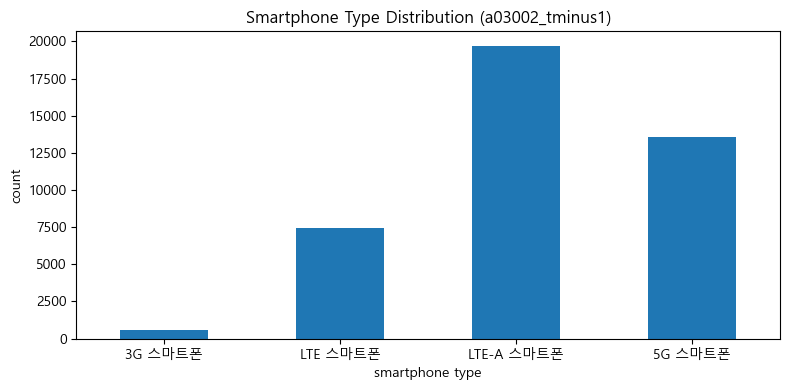


1. a03002_tminus1 : 스마트폰 구분
a03002_tminus1
3G 스마트폰         571
LTE 스마트폰       7469
LTE-A 스마트폰    19693
5G 스마트폰       13566
Name: count, dtype: int64

[해석] 스마트폰 구분
- 이 변수는 t-1 시점에 사용 중인 스마트폰의 통신 기술 세대를 의미한다.
- 사용자가 어느 정도 최신 기술 환경에 있는지를 보여주는 변수다.
- 5G 비중이 높으면 최신 단말과 고가 요금제 사용 가능성이 높을 수 있다.
- 이 변수는 숫자가 아니라 기술 세대에 대한 범주형 변수로 해석하는 것이 적절하다.


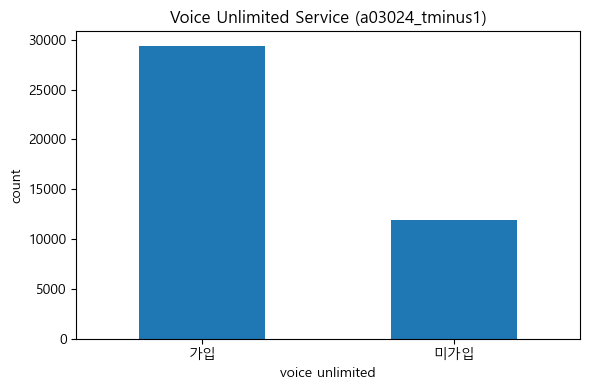


2. a03024_tminus1 : 음성 무제한 서비스 가입 여부
a03024_tminus1
가입     29370
미가입    11929
Name: count, dtype: int64

[해석] 음성 무제한 가입 여부
- 이 변수는 t-1 시점에 음성 통화 무제한 서비스에 가입했는지를 나타낸다.
- 가입 비중이 높다면 현재 통신사에서 음성 혜택을 충분히 받고 있는 사용자가 많다는 뜻일 수 있다.
- 전처리 후에는 1=가입, 0=미가입으로 바뀐 상태다.


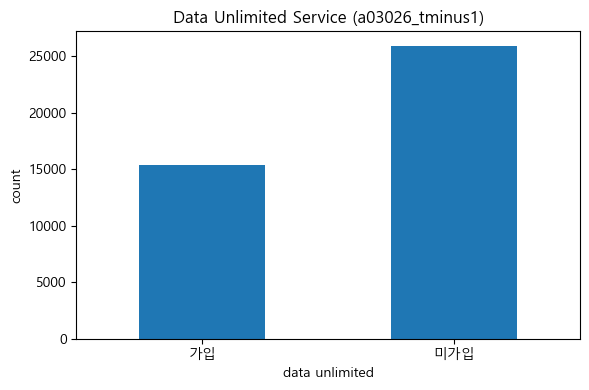


3. a03026_tminus1 : 데이터 무제한 서비스 가입 여부
a03026_tminus1
가입     15404
미가입    25895
Name: count, dtype: int64

[해석] 데이터 무제한 가입 여부
- 이 변수는 t-1 시점에 데이터 무제한 서비스에 가입했는지를 나타낸다.
- 데이터 무제한 가입자는 일반적으로 데이터 사용량이 많거나, 품질/속도에 민감할 가능성이 있다.
- MVNO 이동은 비용 민감성과 관련될 수 있으므로, 이 변수는 churn_to_mvno와 연결해 해석할 가치가 있다.


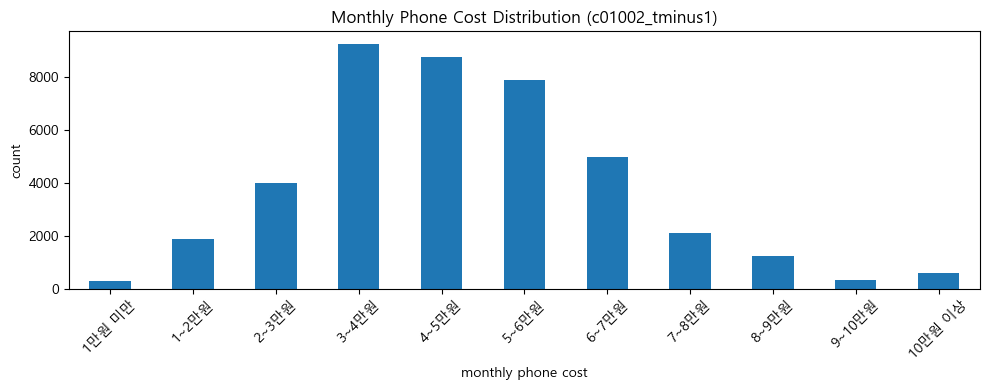


4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액
c01002_tminus1
1만원 미만      299
1~2만원      1877
2~3만원      3977
3~4만원      9241
4~5만원      8747
5~6만원      7870
6~7만원      4971
7~8만원      2115
8~9만원      1259
9~10만원      346
10만원 이상     597
Name: count, dtype: int64

[해석] 월평균 휴대폰 이용 총 금액
- 이 변수는 t-1 시점의 전체 휴대폰 비용 수준을 구간으로 표현한 변수다.
- 실제 금액이 아니라 비용 구간 코드라는 점이 중요하다.
- 어느 구간에 관측치가 많이 몰려 있는지 보면 전체 이용자들의 요금 수준을 대략 파악할 수 있다.
- 통신비 부담 수준을 가장 직접적으로 보여주는 핵심 입력 변수 중 하나다.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# 0. 데이터 불러오기
# ---------------------------------------
df = pd.read_csv("../data/processed/train_df_2020_2025.csv", encoding="utf-8-sig")

# 보기 쉬운 라벨 매핑
a03002_map = {
    1.0: "3G 스마트폰",
    2.0: "LTE 스마트폰",
    3.0: "LTE-A 스마트폰",
    4.0: "5G 스마트폰"
}

binary_map = {
    0.0: "미가입",
    1.0: "가입"
}

cost_map = {
    1.0: "1만원 미만",
    2.0: "1~2만원",
    3.0: "2~3만원",
    4.0: "3~4만원",
    5.0: "4~5만원",
    6.0: "5~6만원",
    7.0: "6~7만원",
    8.0: "7~8만원",
    9.0: "8~9만원",
    10.0: "9~10만원",
    11.0: "10만원 이상"
}

# ---------------------------------------
# 1. a03002_tminus1 : 스마트폰 구분
# ---------------------------------------
smartphone_counts = df["a03002_tminus1"].map(a03002_map).value_counts().reindex(
    ["3G 스마트폰", "LTE 스마트폰", "LTE-A 스마트폰", "5G 스마트폰"]
)

plt.figure(figsize=(8, 4))
smartphone_counts.plot(kind="bar")
plt.title("Smartphone Type Distribution (a03002_tminus1)")
plt.xlabel("smartphone type")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("1. a03002_tminus1 : 스마트폰 구분")
print("=" * 70)
print(smartphone_counts)

print("\n[해석] 스마트폰 구분")
print("- 이 변수는 t-1 시점에 사용 중인 스마트폰의 통신 기술 세대를 의미한다.")
print("- 사용자가 어느 정도 최신 기술 환경에 있는지를 보여주는 변수다.")
print("- 5G 비중이 높으면 최신 단말과 고가 요금제 사용 가능성이 높을 수 있다.")
print("- 이 변수는 숫자가 아니라 기술 세대에 대한 범주형 변수로 해석하는 것이 적절하다.")

# ---------------------------------------
# 2. a03024_tminus1 : 음성 무제한 가입 여부
# ---------------------------------------
voice_counts = df["a03024_tminus1"].map(binary_map).value_counts().reindex(["가입", "미가입"])

plt.figure(figsize=(6, 4))
voice_counts.plot(kind="bar")
plt.title("Voice Unlimited Service (a03024_tminus1)")
plt.xlabel("voice unlimited")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("2. a03024_tminus1 : 음성 무제한 서비스 가입 여부")
print("=" * 70)
print(voice_counts)

print("\n[해석] 음성 무제한 가입 여부")
print("- 이 변수는 t-1 시점에 음성 통화 무제한 서비스에 가입했는지를 나타낸다.")
print("- 가입 비중이 높다면 현재 통신사에서 음성 혜택을 충분히 받고 있는 사용자가 많다는 뜻일 수 있다.")
print("- 전처리 후에는 1=가입, 0=미가입으로 바뀐 상태다.")

# ---------------------------------------
# 3. a03026_tminus1 : 데이터 무제한 가입 여부
# ---------------------------------------
data_counts = df["a03026_tminus1"].map(binary_map).value_counts().reindex(["가입", "미가입"])

plt.figure(figsize=(6, 4))
data_counts.plot(kind="bar")
plt.title("Data Unlimited Service (a03026_tminus1)")
plt.xlabel("data unlimited")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("3. a03026_tminus1 : 데이터 무제한 서비스 가입 여부")
print("=" * 70)
print(data_counts)

print("\n[해석] 데이터 무제한 가입 여부")
print("- 이 변수는 t-1 시점에 데이터 무제한 서비스에 가입했는지를 나타낸다.")
print("- 데이터 무제한 가입자는 일반적으로 데이터 사용량이 많거나, 품질/속도에 민감할 가능성이 있다.")
print("- MVNO 이동은 비용 민감성과 관련될 수 있으므로, 이 변수는 churn_to_mvno와 연결해 해석할 가치가 있다.")

# ---------------------------------------
# 4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액
# ---------------------------------------
cost_counts = df["c01002_tminus1"].map(cost_map).value_counts().reindex([
    "1만원 미만", "1~2만원", "2~3만원", "3~4만원", "4~5만원",
    "5~6만원", "6~7만원", "7~8만원", "8~9만원", "9~10만원", "10만원 이상"
])

plt.figure(figsize=(10, 4))
cost_counts.plot(kind="bar")
plt.title("Monthly Phone Cost Distribution (c01002_tminus1)")
plt.xlabel("monthly phone cost")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액")
print("=" * 70)
print(cost_counts)

print("\n[해석] 월평균 휴대폰 이용 총 금액")
print("- 이 변수는 t-1 시점의 전체 휴대폰 비용 수준을 구간으로 표현한 변수다.")
print("- 실제 금액이 아니라 비용 구간 코드라는 점이 중요하다.")
print("- 어느 구간에 관측치가 많이 몰려 있는지 보면 전체 이용자들의 요금 수준을 대략 파악할 수 있다.")
print("- 통신비 부담 수준을 가장 직접적으로 보여주는 핵심 입력 변수 중 하나다.")

## 3. 요약

이 노트북을 통해 다음을 확인할 수 있다.

- 전처리 데이터는 개인별 연도 전환(`t-1 → t`) 단위로 구성되어 있다.
- `churn_any`는 전체 통신사 이동을, `churn_to_mvno`는 메이저 → MVNO 이동을 의미한다.
- 연도 전환 구간별 표본 수와 시작 통신사 분포를 확인할 수 있다.
- 통신사 이동 heatmap을 통해 실제 이동 방향을 직관적으로 볼 수 있다.
- 주요 입력 변수 분포를 통해 사용자 기술 수준, 무제한 서비스 가입 여부, 통신비 수준 등을 파악할 수 있다.